<a href="https://colab.research.google.com/github/EgorMatveev26/MO_Attack/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 8. Физические adversarial-атаки: adversarial patches, дорожные знаки, состязательная одежда

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 6**


**Вариант / seed:** 3

### Таблица вариантов

| Вариант | `SEED` | Разрешение `RES` | Частота складок `FREQ` | Дополнительное условие части E |
|---|---|---|---|---|
| 1 | 42 | 16 | 1.5 | углы 0–32° с шагом 8° |
| 2 | 7 | 16 | 2.0 | углы 0–40° с шагом 10° |
| 3 | 123 | 20 | 1.5 | углы 0–24° с шагом 6° |
| 4 | 2024 | 20 | 2.2 | углы 0–32° с шагом 8° |
| 5 | 314 | 12 | 1.2 | углы 0–40° с шагом 10° |
| 6 | 555 | 24 | 1.8 | углы 0–24° с шагом 6° |

> Вариант выдаётся преподавателем. Все числовые результаты в отчёте должны соответствовать
> **вашему** варианту, а не значениям из примера.

### Цель работы

Экспериментально исследовать, почему устойчивость модели компьютерного зрения к физическим
adversarial-атакам не определяется её точностью на цифровых изображениях, и оценить
эффективность базовых защитных мер.

### Задачи

1. Построить учебный стенд компьютерного зрения и измерить базовую точность.
2. Реализовать имитацию физического канала наблюдения и оценить влияние отдельных факторов съёмки.
3. Исследовать локальность патча: зависимость деградации от площади и положения области.
4. Применить логику Expectation over Transformation при оценке устойчивости.
5. Построить карту качества жёсткого объекта в координатах «дистанция × ракурс».
6. Смоделировать не-жёсткие деформации ткани и сравнить их с жёстким преобразованием.
7. Обучить модель с физически правдоподобными аугментациями и оценить прирост устойчивости.
8. Проверить эффект временной агрегации решений по кадрам.
9. Сформулировать выводы и заполнить сводную таблицу отчёта.

### Ограничение

Работа выполняется **только** на синтетическом учебном наборе и локальных моделях. Запрещается
использовать код работы для воздействия на реальные системы восприятия, камеры, внешние сервисы
и любые эксплуатируемые объекты. Печатаемые атакующие шаблоны в работе не создаются.

## Краткая теория

Физическая атака изменяет **объект в сцене**, а не входной тензор модели. Наблюдение описывается как

$
x_{\text{cam}} = T_\theta\big(x \odot (1 - M) + p \odot M\big), \qquad \theta \sim \mathcal{D}_{\text{физ}},
$

где $M$ — маска области патча, $p$ — его содержимое, $T_\theta$ — преобразование при параметрах
съёмки $\theta$ (ракурс, дистанция, освещение, оптика, обработка изображения).

Требование робастности возмущения формализует Expectation over Transformation:

$
\max_{p}\; \mathbb{E}_{\theta \sim \mathcal{D}}\Big[\mathcal{L}\big(f(T_\theta(x, p, M)),\, y_{\text{target}}\big)\Big].
$

**Задание 0.** Заполните таблицу различий трёх постановок (ячейки со знаком «?»):

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| Что изменяется | Значения пикселей входного изображения | Внешний вид патча, наклеенного на поверхность дорожного знака | Рисунок и текстура ткани на одежде человека |
| Ограничение возмущения | Малая норма отклонения пикселей от исходных | Форма, размер и место патча, а также возможность его напечатать | Возможность нанести рисунок на ткань и сохранить его при движении |
| Обязательные члены $\mathcal{D}$ | Обычно отсутствуют, иногда добавляют небольшой шум | Угол обзора, расстояние до знака, освещение, оптика камеры, обработка снимка | Все то же, что и для знака, плюс складки, растяжение ткани, смена позы, перекрытие частей тела, движение в кадре |
| Основная сложность | Подбор возмущения в допустимых границах | Учет условий съемки при подборе патча | Сложная форма тела и постоянные изменения ткани при движении |
| Типичная метрика | Доля успешных атак при заданной силе возмущения | Доля успешных атак, усредненная по условиям съемки | Доля успешных атак с учетом деформаций и движения, а также качество обнаружения на детекторе |

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [ ]:
# TODO A.1: подставьте значения своего варианта из таблицы вариантов
SEED = 123   # например 42
RES = 20    # например 16
FREQ = 1.5   # например 1.5

assert SEED is not None and RES is not None and FREQ is not None, "Задайте параметры варианта"

RES = 20×20 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.956


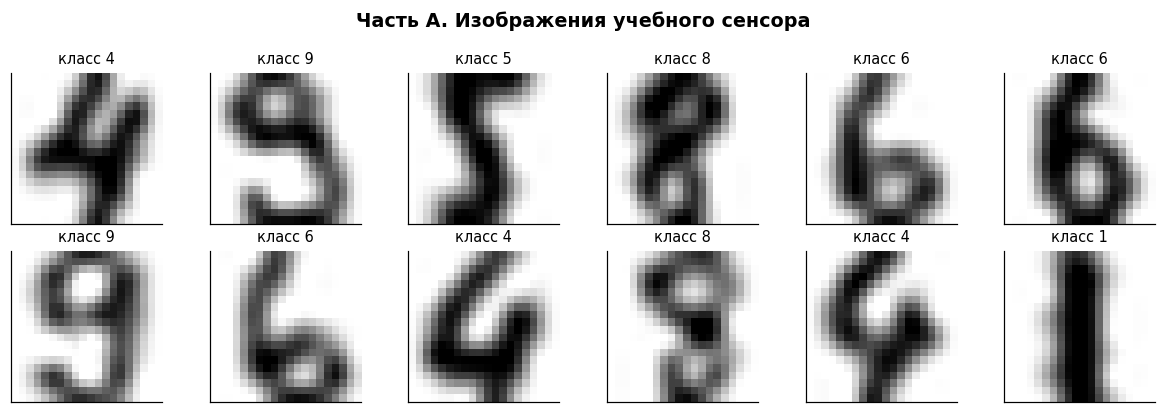

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

датасет 20х20 (обучающая выборка 1257, тестовая 540), базовая точность 0.956, 12 примеров изображений учебного сенсора с подписями истинных классов

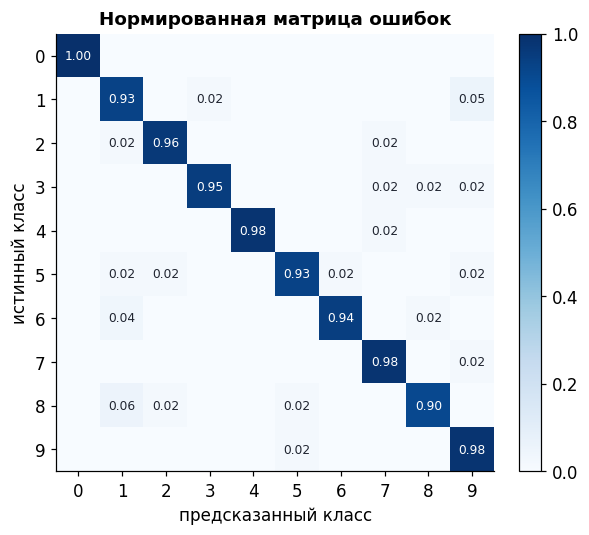

In [ ]:
# TODO A.3: постройте нормированную матрицу ошибок базовой модели.
# Подсказка: confusion_matrix(..., normalize="true"), затем imshow с colorbar.

y_pred = baseline.predict(flat(X_test_img))
cm = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("предсказанный класс"); ax.set_ylabel("истинный класс")
ax.set_title("Нормированная матрица ошибок")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0.01:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > 0.5 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.grid(False)
plt.tight_layout()
plt.show()

Основная путаница приходится на пару классов 8 и 1 и на класс 1 с классом 9

**Отчёт по части A.** Заполните:

| Показатель | Ваше значение |
|---|---|
| `SEED` / `RES` |123/20 |
| Размер обучающей выборки |1257 |
| Базовая точность `acc_clean` |0.956 |
| Две пары классов с наибольшей путаницей |8 и 1; 1 и 9 |

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы
с физическими объектами? Обоснуйте.

Ответ: Нет, нельзя, так как acc_clean показывает, как модель работает на идеальных картинках, а в реальной жизни камера снимает под углом, с другого расстояния, при плохом свете и с помехами, поэтому даже отличная точность на тесте ничего не говорит о том, как модель поведёт себя на настоящем объекте.

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [ ]:
def resize_to_shape(image, shape):
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [ ]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    # поворот и масштаб уже реализованы
    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # TODO B.1: контраст относительно середины диапазона: (out - 0.5) * contrast + 0.5
    out = (out - 0.5) * contrast + 0.5
    # TODO B.2: яркость: умножение на brightness
    out = out * brightness
    # TODO B.3: размытие оптики: gaussian_filter(out, sigma=blur), если blur > 0
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)
    # TODO B.4: шум сенсора: прибавьте gen.normal(0, noise, out.shape), если noise > 0
    if noise > 0:
        out = out + gen.normal(0, noise, out.shape)
    # TODO B.5: окклюзия: occlusion = (r0, r1, c0, c1, value) -> присвоить value этому окну
    if occlusion is not None:
        r0, r1, c0, c1, value = occlusion
        out[r0:r1, c0:c1] = value

    return np.clip(out, 0.0, 1.0).astype(np.float32)


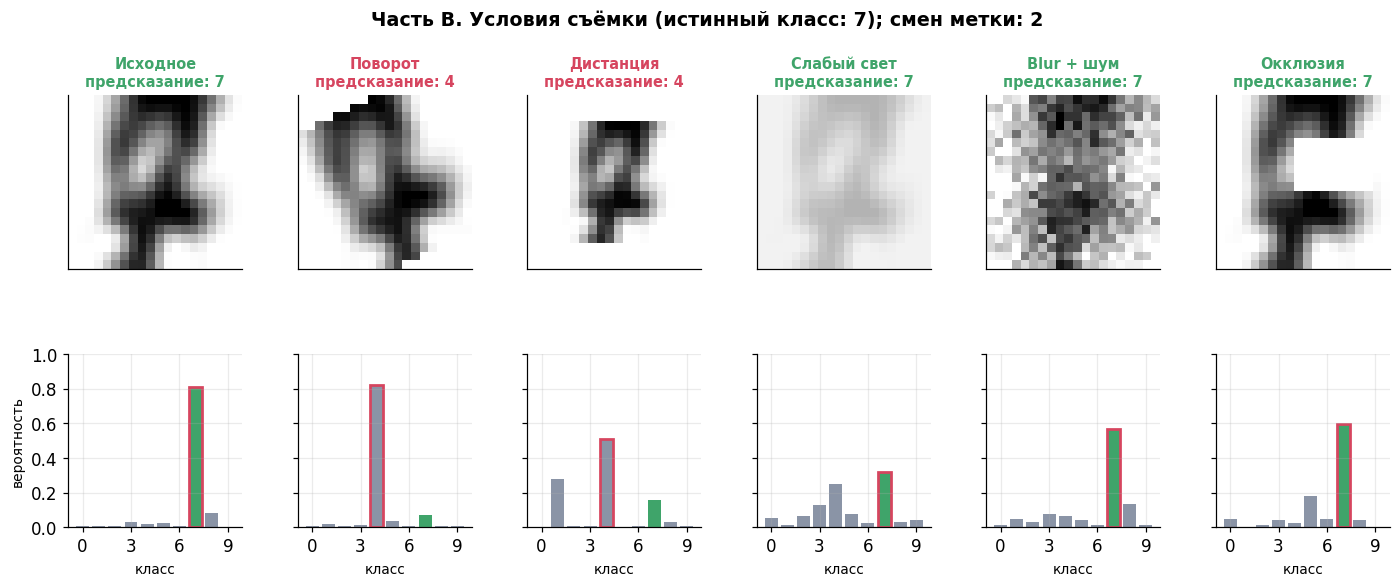

B.7 Число режимов со сменой метки: 2 (требуется не менее 2)


In [ ]:
# TODO B.6: выберите объект-пример и подберите параметры так, чтобы МИНИМУМ два режима
# приводили к смене предсказанной метки. Значения ниже — стартовые, их нужно изменить.
idx = 9
example, true_label = X_test_img[idx], y_test[idx]

conditions = [
    ("Исходное",        dict()),
    ("Поворот",         dict(angle=28)),
    ("Дистанция",       dict(scale=0.72)),
    ("Слабый свет",     dict(brightness=0.35, contrast=0.70)),
    ("Blur + шум",      dict(blur=2.0, noise=0.15)),
    ("Окклюзия",        dict(occlusion=(RES // 4, RES // 4 + RES // 3, RES // 2 - 1, RES - 2, 0.0))),
]

fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.4),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.30, "wspace": 0.32})
flips = 0
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba)); ok = pred == true_label
    flips += (not ok)
    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}", fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    bars = axes[1, col].bar(range(10), proba,
                           color=[PALETTE["robust"] if k == true_label else PALETTE["gray"] for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"B.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")

смена метки произошла при повороте цифры на 28 градусов и при уменьшении до 72% от исходного размера

**Отчёт по части B.** Заполните таблицу по своим значениям:

| Режим | Предсказание | Вероятность истинного класса | Метка изменилась? |
|---|---|---|---|
| Исходное |7 |0.8 | нет|
| Поворот |4 |0.07 |да |
| Дистанция |4 |0.18 |да |
| Слабый свет | 7|0.32 | нет|
| Blur + шум |7 |0.58 | нет|
| Окклюзия | 7|0.6 |нет |

**Вопрос B.** Какой фактор в вашем эксперименте оказался наиболее разрушительным и почему?
Отличается ли ответ для другого объекта-примера?

Ответ: Самые разрушительные это поворот и уменьшение дистанции: в обоих случаях модель вместо 7 говорила 4, потому что она училась на ровных цифрах обычного размера. Для другой цифры тоже будет по-разному: тонкие цифры плохо видны, когда картинка мутная, а толстые когда часть закрыта или плохо видно из-за света.

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

In [ ]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    """Возвращает (изображение с маркером, бинарную маску маркера)."""
    if size is None:
        size = max(3, RES // 3)
    # TODO C.1: скопируйте изображение, впишите значение value в окно
    # [top:top+size, left:left+size] и постройте маску той же формы
    result = image.copy()
    mask = np.zeros_like(image, dtype=np.float32)
    r1 = min(top + size, image.shape[0])
    c1 = min(left + size, image.shape[1])
    result[top:r1, left:c1] = value
    mask[top:r1, left:c1] = 1.0
    return result, mask

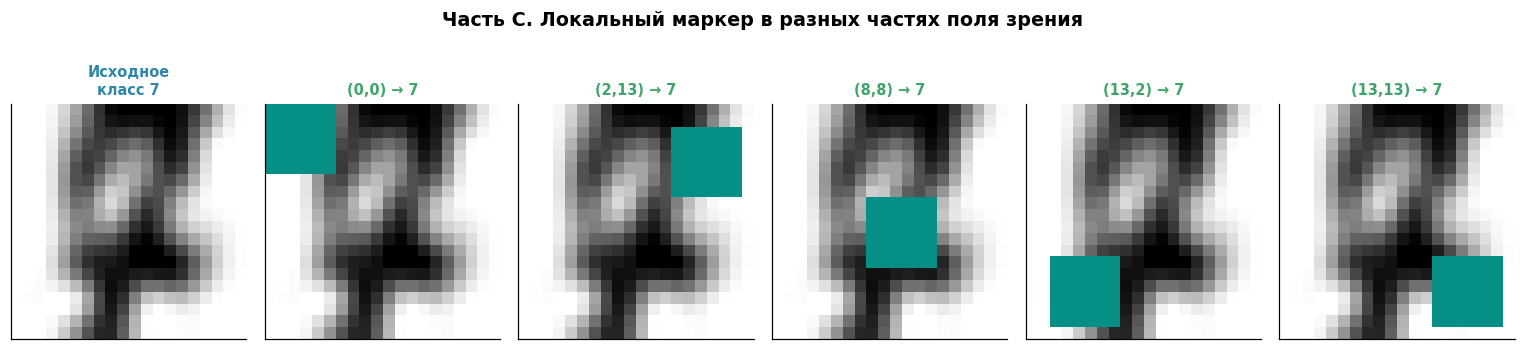

In [ ]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1,
              alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

для цифры 7 маркер нигде не сломал предсказание

In [ ]:
# TODO C.2: заполните карту точности pos_map по позициям маркера на всей тестовой выборке.
# TODO C.3: заполните списки area_acc и area_frac для кривой деградации по площади.

stride = max(1, RES // 8)
grid_pos = list(range(0, RES - MARKER + 1, stride))
pos_map = np.zeros((len(grid_pos), len(grid_pos)))
for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        # ваш код: accuracy_score на выборке с маркером в (r, c)
        marked = np.asarray([apply_marker(im, r, c, MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked)))

sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    # ваш код: добавьте accuracy и долю площади 100*s*s/RES**2
    if s == 0:
        area_acc.append(acc_clean)
        area_frac.append(0.0)
        continue
    marked = np.asarray([apply_marker(im, RES // 2 - s // 2, RES // 2 - s // 2, s)[0]
                         for im in X_test_img])
    area_acc.append(accuracy_score(y_test, baseline.predict(flat(marked))))
    area_frac.append(100.0 * s * s / RES**2)

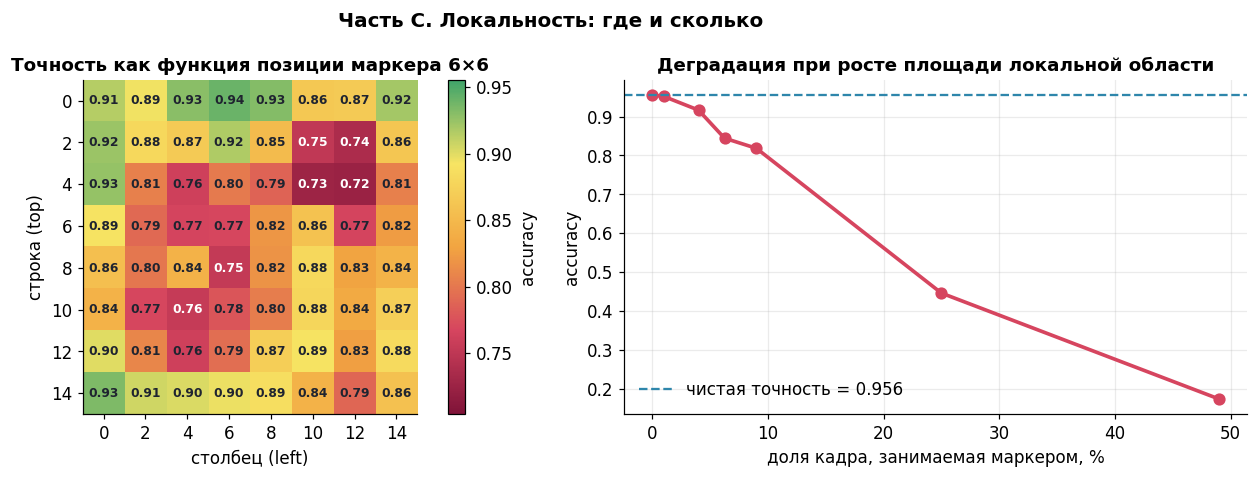

C.4 Худшая позиция: (4, 12) → accuracy 0.724
C.5 Лучшая позиция: accuracy 0.941; разница 0.217


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

**Отчёт по части C.**

| Показатель | Ваше значение |
|---|---|
| Сторона маркера `MARKER` | 6|
| Худшая позиция и её accuracy |(4, 12); 0.724 |
| Лучшая позиция и её accuracy |(0, 6); 0.941 |
| Разница между худшей и лучшей позицией |0.217 |
| Площадь, при которой accuracy падает ниже 0.5, % |23% |

**Вопрос C.** Почему при одинаковой площади результат зависит от положения области?
Свяжите ответ с тем, какие части объекта информативны для модели.

Ответ: Положение маркера важно, потому что цифра занимает не всю картинку, ее штрихи находятся в центре. Если маркер попадает в центр, он закрывает важные для модели пиксели, и она ошибается. Если маркер в углу, там и так пусто, поэтому модель почти не замечает помеху. Поэтому при одинаковой площади результат сильно зависит от того, куда именно попал маркер.

## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

In [ ]:
def sample_params(gen, severity=1.0):
    """Случайные параметры съёмки; severity масштабирует весь диапазон условий."""
    # TODO D.1: верните словарь с ключами angle, scale, brightness, contrast, blur, noise.
    # Ориентировочные диапазоны при severity = 1:
    #   angle ±17°, scale 0.83–1.13, brightness 0.74–1.20,
    #   contrast 0.80–1.20, blur 0–0.85, noise 0–0.055
    return dict(
        angle      = gen.uniform(-17, 17) * severity,
        scale      = 1.0 + (gen.uniform(0.83, 1.13) - 1.0) * severity,
        brightness = 1.0 + (gen.uniform(0.74, 1.20) - 1.0) * severity,
        contrast   = 1.0 + (gen.uniform(0.80, 1.20) - 1.0) * severity,
        blur       = gen.uniform(0, 0.85) * severity,
        noise      = gen.uniform(0, 0.055) * severity,
    )


def transformed_dataset(imgs, gen, severity=1.0):
    # TODO D.2: примените physical_transform со случайными параметрами к каждому изображению
    out = np.empty_like(imgs)
    for i, im in enumerate(imgs):
        params = sample_params(gen, severity)
        out[i] = physical_transform(im, **params, generator=gen)
    return out

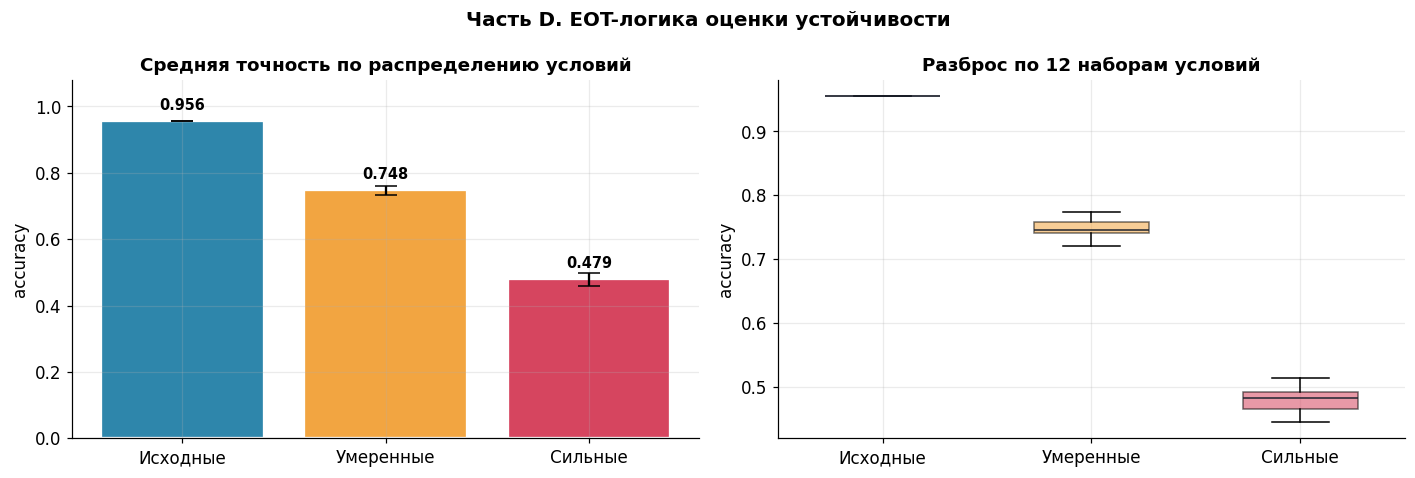

D.3 Исходные   accuracy = 0.956 ± 0.000
D.3 Умеренные  accuracy = 0.748 ± 0.014
D.3 Сильные    accuracy = 0.479 ± 0.020


In [ ]:
REPEATS = 12
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        samples[name] = [acc_clean] * REPEATS
    else:
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

names = [n for n, _, _ in regimes]
means = [float(np.mean(samples[n])) for n in names]
stds = [float(np.std(samples[n])) for n in names]
colors = [c for _, _, c in regimes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")
fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

смотрим как меняется точность модели, если много раз подряд снимать цифры в плохих условиях, без искажений все отлично, с умеренными искажениями модель начинает ошибаться в каждом четвертом случае, а при сильном искажении ошибается в половине случаев

**Отчёт по части D.**

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные | 0.956| 0|0 |
| Умеренные | 0.748| 0.014|-0.208 |
| Сильные |0.479 |0.020 | -0.477|

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели?
Как связаны величина `severity` и стандартное отклонение?

Ответ: Один кадр может обмануть, если случайно попадется легкий набор условий, то и точность окажется завышенной. Чтобы получить честную оценку, нужно много раз повторить с разными условиями и усреднить. С ростом severity растет и разброс (стандартное отклонение).

## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [ ]:
# TODO E.1: задайте углы согласно своему варианту
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 6, 12, 18, 24]   # Вариант 3: 0–24° с шагом 6°

# TODO E.2: заполните матрицу grid: строки — углы, столбцы — масштабы
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([physical_transform(im, angle=a, scale=s, brightness=0.95,
                                               blur=0.25, generator=gen) for im in X_test_img])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

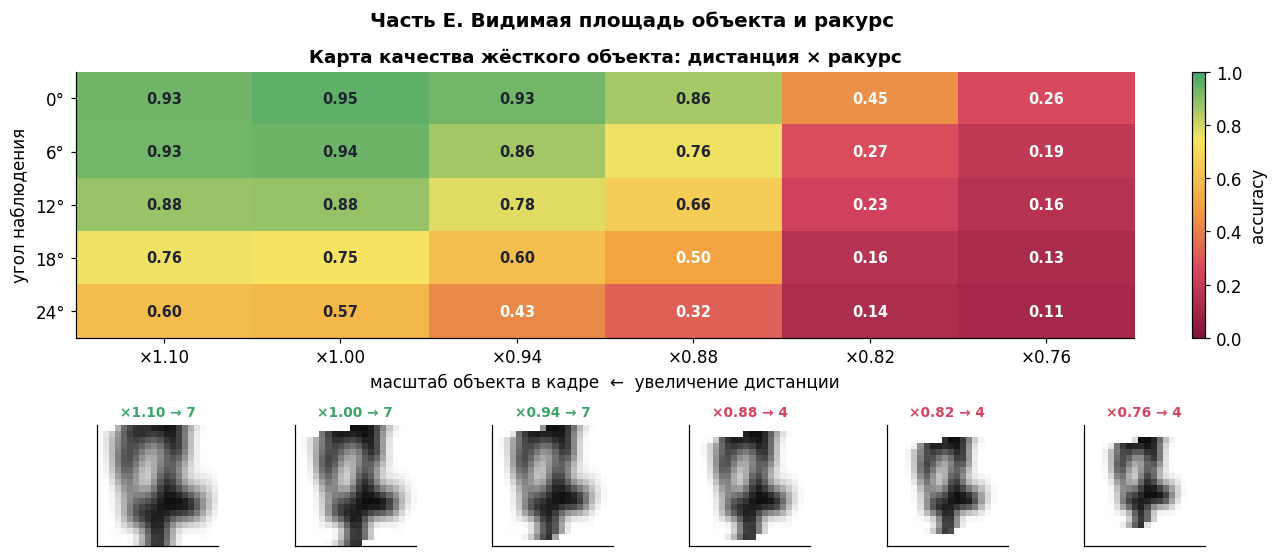

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
     6°: ×1.10, ×1.00, ×0.94, ×0.88
    12°: ×1.10, ×1.00, ×0.94
    18°: ×1.10, ×1.00
    24°: нет


In [ ]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")

карта качества модели для цифры 7 в зависимости от угла, под которым камера смотрит на объект и от масштаба объекта в кадре

**Отчёт по части E.**

| Показатель | Ваше значение |
|---|---|
| Углы варианта |0, 6, 12, 18, 24 |
| Максимальная accuracy в карте | 0.95|
| Минимальная accuracy в карте | 0.11|
| Наибольший допустимый угол при accuracy ≥ 0.70 |18 град., но зависит от масштаба объекта в кадре |
| Наименьший допустимый масштаб при accuracy ≥ 0.70 |х0.88, при этом также зависит от угла наблюдения |

**Вопрос E.** Как связаны видимая площадь знака в кадре и успех физической атаки?
Чем отличается атака на классификатор от атаки на детектор в конвейере автономного вождения?

Ответ: Мелкий знак в кадре атаковать легче, крупный труднее. Классификатору достаточно подменить метку, а детектору нужно еще сломать поиск рамки, поэтому атака на детектор сложнее и требует более хитрых патчей.

## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

In [ ]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    # TODO F.1: поле смещений по столбцам: amplitude * sin(2*pi*frequency*rr/h + phase)
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)
    # TODO F.2: поперечное поле по строкам с коэффициентом 0.45
    shift_r = 0.45 * amplitude * np.sin(2 * np.pi * frequency * cc / w + phase)
    # TODO F.3: примените map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    warped = map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    return np.clip(warped, 0, 1).astype(np.float32)

In [ ]:
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

# TODO F.4: заполните warp_acc (деформация ткани) и rigid_acc (жёсткий поворот на a * 6 градусов)
warp_acc, rigid_acc = [], []
for a in amps:
    warped = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warped))))

    rotated = np.asarray([physical_transform(im, angle=a * 6) for im in X_test_img])
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rotated))))

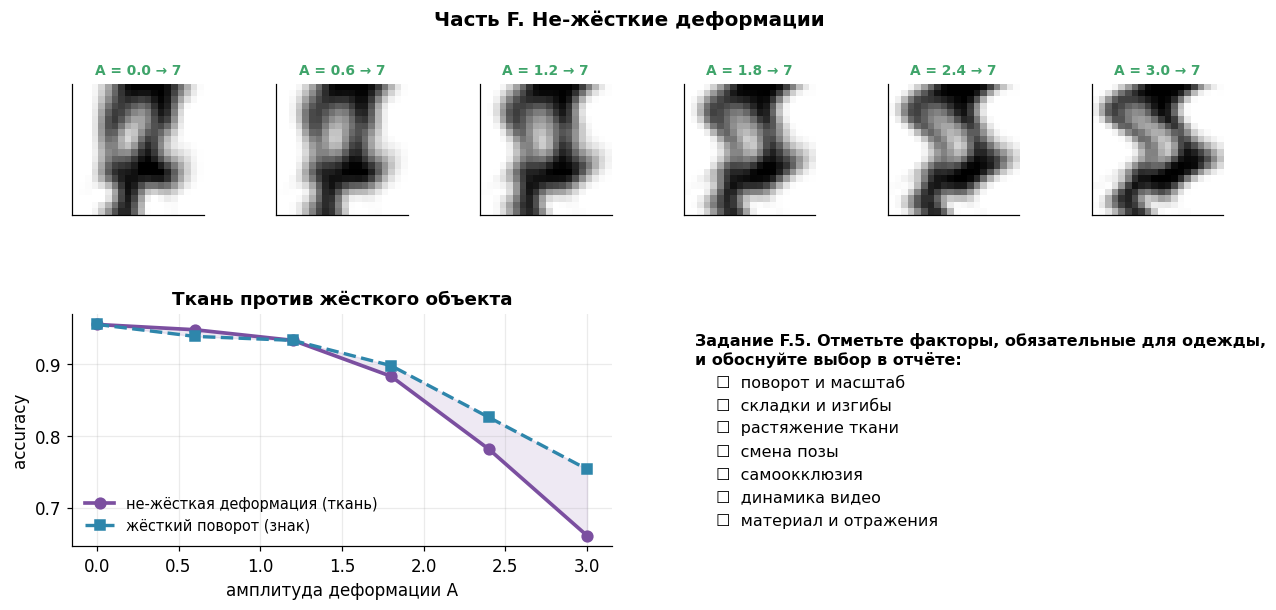

F.6 accuracy при максимальной деформации: ткань 0.661 против жёсткого поворота 0.754


In [ ]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

при максимальной деформации ткань даёт точность 0.661, а жёсткий поворот 0.754. то есть ткань ломает модель сильнее, чем поворот той же силы.

жесткий знак не гнется, не растягивается и не меняет позу, для него хватает поворота и масштаба. а одежда на человеке мнется, тянется, меняет форму при движении, части тела перекрывают друг друга. поэтому в распределение
D для одежды нужно добавлять все эти факторы, иначе атака не сработает в реальности.

In [ ]:
print("A     ткань    поворот")
for a, w, r in zip(amps, warp_acc, rigid_acc):
    print(f"{a:.1f}   {w:.3f}    {r:.3f}    разница {w - r:+.3f}")

A     ткань    поворот
0.0   0.956    0.956    разница +0.000
0.6   0.948    0.939    разница +0.009
1.2   0.933    0.933    разница +0.000
1.8   0.883    0.898    разница -0.015
2.4   0.781    0.826    разница -0.044
3.0   0.661    0.754    разница -0.093


**Отчёт по части F.**

| A | accuracy (ткань) | accuracy (жёсткий поворот) | Разница |
|---|---|---|---|
| 0.0 |0.956 |0.956 |0 |
| 1.2 |0.933 |0.933 |0 |
| 2.4 |0.781 |0.826 |-0.44 |
| 3.0 |0.661 |0.754 |-0.093 |

**Вопрос F.** Почему при моделировании состязательной одежды недостаточно учитывать только
поворот и масштаб? Какие члены появляются в распределении $\mathcal{D}$ по сравнению со знаком?

Ответ: Знак не гнется и ему хватает поворота и масштаба. А одежда на человеке все время мнется, тянется и меняет форму, поэтому в распределении D приходится добавлять складки, растяжение, смену позы, самоокклюзию, движение и свойства ткани. Без этого атака будет работать только на неподвижном манекене, но не на живом человеке.

## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [ ]:
# TODO G.1: сформируйте аугментированную выборку: исходные данные + 4 копии со случайными
# условиями съёмки (severity ≈ 1.3) + 1 копия с деформацией ткани (amplitude 0.5–2.5).
aug_gen = np.random.default_rng(SEED + 5)

parts = [X_train_img]
for _ in range(4):
    parts.append(transformed_dataset(X_train_img, aug_gen, severity=1.3))

warped = np.asarray([
    cloth_warp(im, amplitude=aug_gen.uniform(0.5, 2.5),
               frequency=aug_gen.uniform(1.0, 2.0))
    for im in X_train_img
])
parts.append(warped)

X_aug = np.concatenate(parts, axis=0)
y_aug = np.concatenate([y_train] * len(parts), axis=0)

# TODO G.2: обучите модель robust с теми же гиперпараметрами, что у baseline
robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)

обучили вторую модель не на чистых картинках, а на расширенной выборке, где к исходным 1257 картинкам добавили еще 5 копий с искажениями. всего получилось 7542 картинки.

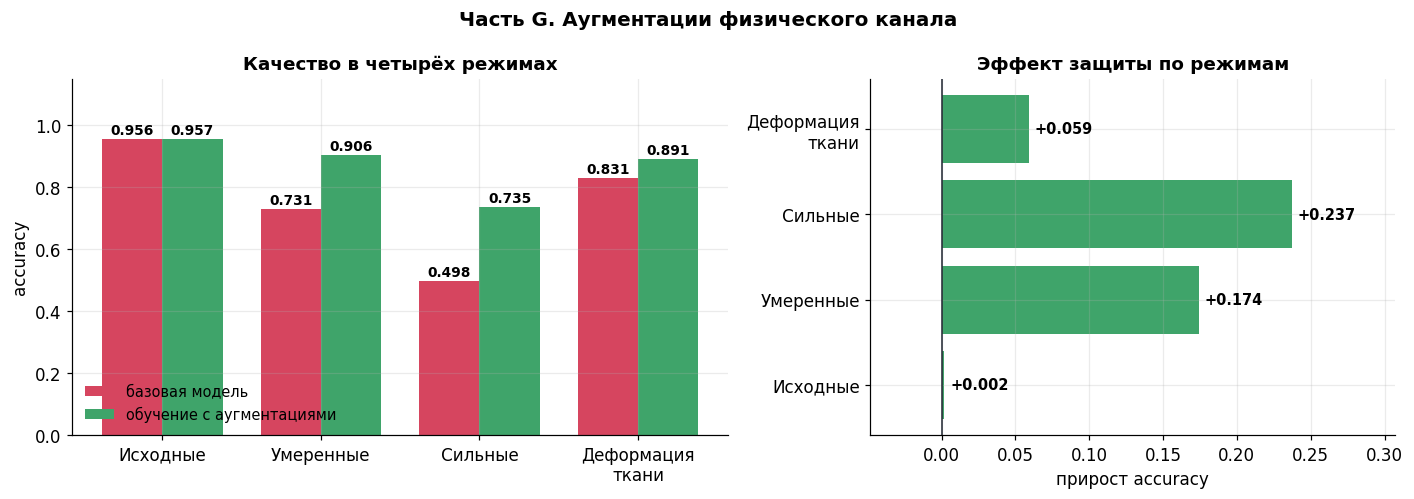

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.956 → защита 0.957 (+0.002)
    Умеренные          база 0.731 → защита 0.906 (+0.174)
    Сильные            база 0.498 → защита 0.735 (+0.237)
    Деформация ткани   база 0.831 → защита 0.891 (+0.059)


In [ ]:
gen = np.random.default_rng(SEED + 2000)
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores = [accuracy_score(y_test, robust.predict(flat(v))) for v in eval_sets.values()]
names_g = list(eval_sets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
xp = np.arange(len(names_g)); wbar = 0.38
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель", color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores, wbar, label="обучение с аугментациями", color=PALETTE["robust"])
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

delta = np.array(rob_scores) - np.array(base_scores)
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)
fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

**Отчёт по части G.**

| Режим | Базовая модель | С аугментациями | Прирост |
|---|---|---|---|
| Исходные |0.956 |0.957 |+0.002 |
| Умеренные |0.731 |0.906 |+0.174 |
| Сильные |0.498 |0.735 |+0.237 |
| Деформация ткани |0.831 |0.891 |+0.059 |

**Вопрос G.** Какова цена робастности в вашем эксперименте? Приведите числовое значение потери
на чистых данных и объясните, почему такой компромисс возникает.

Ответ: Цена робастности в нашем эксперименте практически 0 (+0.002 на чистых данных). Компромисс оказался бесплатным, потому что аугментации просто добавляют модели разные варианты одного объекта, не мешая ей работать на исходных картинках.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

In [ ]:
FRAMES = 24
seq_gen = np.random.default_rng(SEED + 33)
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

# TODO H.1: сформируйте кадры: случайные условия severity ≈ 1.3, а на кадрах 9–14 добавьте окклюзию.
# TODO H.2: соберите probas (вероятности по кадрам) и per_frame_pred (покадровые решения).
frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    params = sample_params(seq_gen, severity=1.3)
    if 9 <= t <= 14:
        params["occlusion"] = occ_window
    frame = physical_transform(example, **params, generator=seq_gen)
    frames.append(frame)
    proba = baseline.predict_proba(flat(frame[None, ...]))[0]
    probas.append(proba)
    per_frame_pred.append(int(np.argmax(proba)))

probas = np.asarray(probas)

# TODO H.3: вместо усреднения вероятностей — голосование по большинству
cum_pred_vote = []
for t in range(1, FRAMES + 1):
    # смотрим покадровые решения с 0-го по (t-1)-й кадр
    votes = per_frame_pred[:t]
    # берём класс, который встречается чаще всего
    counts = np.bincount(votes, minlength=10)
    cum_pred_vote.append(int(np.argmax(counts)))
cum_pred_vote = np.asarray(cum_pred_vote)

# уверенность агрегированного решения (для сравнения) — оставляем как было
cum_mean = np.cumsum(probas, axis=0) / np.arange(1, FRAMES + 1)[:, None]
cum_pred = np.argmax(cum_mean, axis=1)
cum_conf = cum_mean[:, true_label]
per_frame_conf = probas[:, true_label]

# сравнение: с какого кадра стабильно верно каждое правило
stable_mean = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
stable_vote = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred_vote[t:])), None)

print(f"H.7 Усреднение вероятностей: стабильно верно с кадра {stable_mean}")
print(f"H.7 Голосование по большинству: стабильно верно с кадра {stable_vote}")

H.7 Усреднение вероятностей: стабильно верно с кадра 1
H.7 Голосование по большинству: стабильно верно с кадра 2


усреднение дает более плавную кривую уверенности, а голосование ступенчатую, потому что оно работает только с метками классов, а не с их вероятностями

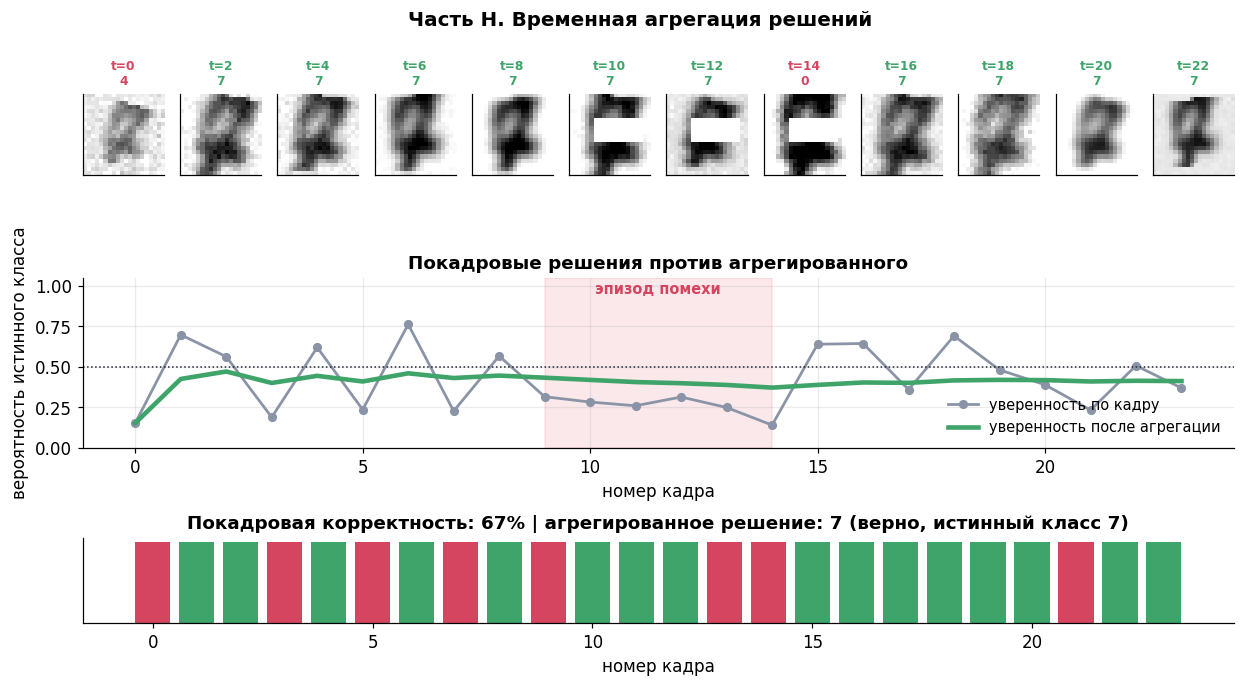

H.4 Покадровая корректность: 0.667
H.5 Агрегированное решение: 7 (истинный класс 7)
H.6 Агрегация стабильно верна начиная с кадра: 1


In [ ]:
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
agg_ok = cum_pred[-1] == true_label

fig = plt.figure(figsize=(13.5, 6.4))
gs = fig.add_gridspec(3, 12, height_ratios=[1.0, 1.6, 0.8], hspace=0.75)
for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t * 2])
    ok = per_frame_pred[t * 2] == true_label
    ax.set_title(f"t={t*2}\n{per_frame_pred[t*2]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

ax1 = fig.add_subplot(gs[1, :])
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"], linewidth=1.8, markersize=5,
         label="уверенность по кадру")
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
         label="уверенность после агрегации")
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5, color=PALETTE["severe"], fontweight="bold")
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса"); ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

ax2 = fig.add_subplot(gs[2, :])
correct = np.array([p == true_label for p in per_frame_pred])
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")
fig.suptitle("Часть H. Временная агрегация решений", fontsize=13, fontweight="bold")
plt.show()

stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

Мы сгенерировали 24 кадра одного и того же объекта (цифры 7), каждый раз в новых случайных условиях съёмки — поворот, масштаб, размытие, шум. На кадрах 9–14 дополнительно добавили окклюзию (чёрный прямоугольник посередине).

**Отчёт по части H.**

| Показатель | Ваше значение |
|---|---|
| Доля верных отдельных кадров | 0.667|
| Итоговое агрегированное решение |7(истинный класс) |
| Номер кадра, с которого агрегация стабильно верна | 1|

**Задание H.7 (дополнительное).** Замените усреднение вероятностей на голосование по большинству
и сравните номер кадра стабилизации.

Ответ: 2 кадр

## Часть I. Итоговый анализ

### Сводная таблица результатов

Заполните по результатам своего варианта:

| Режим | accuracy | Падение относительно `acc_clean` | Комментарий |
|---|---|---|---|
| Идеальные условия |0.956 | — | базовая модель на чистых данных|
| Умеренные условия |0.748 |-0.208 |severity=1.0 |
| Сильные условия |0.479 |-0.477 |severity=1.8 |
| Локальный маркер, худшая позиция |0.724 |-0.232 |позиция (4, 12); маркер 6х6 |
| Максимальная дистанция и ракурс |0.11 |-0.846 |масштаб х0.76, угол 24 град. |
| Максимальная деформация ткани |0.661 |-0.295 |амплитуда деформации = 3 |
| Аугментации, сильные условия |0.735 |-0.221 |прирост на 0.237 по сравнению с баз. моделью без аугментации |
| Агрегация кадров |1.0 |0(относительно правильного решения) |покадрово 0.667, агрегация стабилизируется с кадра 1 |

### Выводы

Сформулируйте не менее пяти выводов, опираясь на числа из своих экспериментов:

1. Точность на чистых данных ничего не говорит о физической устойчивости.
2. Положение маркера важнее площади.
3. Дистанция и ракурс - самый разрушительный фактор.
4. Деформация ткани ломает сильнее, чем жесткий поворот.
5. Аугментации - эффективная защита почти без цены.

### Контрольные вопросы

1. Почему ограничение $\|\delta\|_p \le \varepsilon$ недостаточно для описания физической атаки?

Потому что оно про пиксели на картинке, а в реальности меняется сам объект — камера смотрит под углом, издалека, при плохом свете. Патч, который работает в цифре, может сломаться от простого поворота камеры.

2. Чем отличаются метрики ASR и robust ASR и почему вторая, как правило, ниже?

ASR - это доля успешных атак в идеальных условиях. Robust ASR - то же самое, но усредненное по разным условиям съемки, поэтому она всегда ниже

3. Как площадь и положение патча влияют на его эффективность? Приведите числа из части C.

Положение важнее площади: маркер в центре снижает точность до 0.72, а в углу почти не мешает (0.94). По площади: до 10 % кадра модель почти не замечает, а при 25 % точность падает до 0.45.

4. Почему атака на детектор объектов сложнее атаки на классификатор?

Классификатору достаточно подменить метку, а детектору надо еще сломать рамку, то есть заставить ее исчезнуть, сдвинуться или остаться на месте с другим классом.

5. Какие члены распределения $\mathcal{D}$ обязательны для одежды и не нужны для жёсткого знака?

Для одежды нужны складки, растяжение, смена позы, самоокклюзия, движение и блеск ткани. Знак не гнется и не двигается, поэтому ему все это не нужно, хватает поворота, масштаба и света.

6. Почему временная агрегация помогает, но не является полной защитой?

Помогает, потому что усредняет случайные ошибки кадров. Но если помеха есть на всех кадрах, агрегация не спасет, тобишь все кадры будут врать одинаково.

7. Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом съёмки?

Цена робастности это насколько упала точность на чистых данных у устойчивой модели по сравнению с базовой. Одним режимом ограничиваться нельзя, потому что модель может быть устойчива к одному и хрупка к другому.

### Дополнительные задания повышенной сложности (кому интересно)

- Заменить `LogisticRegression` на `MLPClassifier` и повторить части D, E, G. Изменился ли характер деградации?
- Добавить в часть C маркер несимметричной формы (полоса) и сравнить с квадратом равной площади.
- Добавить в `cloth_warp` второе поперечное поле смещений с независимой частотой.
- Прогнать работу для двух дополнительных значений `SEED` и оценить устойчивость выводов.
- Реализовать простейший детектор аномальной локальной области и проверить его на данных части C.

### Чек-лист сдачи

- [ ] Заполнен паспорт работы и указан номер варианта.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях B, C, D, E, F, G, H.
- [ ] В части B достигнуто не менее двух смен предсказанной метки.
- [ ] Заполнены все таблицы отчёта числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–7.
- [ ] Сформулировано не менее пяти выводов.
- [ ] Все графики подписаны и читаемы.


### Литература

- Brown T. et al. Adversarial Patch (2017): <https://arxiv.org/abs/1712.09665>
- Eykholt K. et al. Robust Physical-World Attacks on Deep Learning Visual Classification (2018): <https://arxiv.org/abs/1707.08945>
- Athalye A. et al. Synthesizing Robust Adversarial Examples (2018): <https://arxiv.org/abs/1707.07397>
- Xu K. et al. Adversarial T-shirt! Evading Person Detectors in a Physical World (2020): <https://arxiv.org/abs/1910.11099>
- Thys S. et al. Fooling automated surveillance cameras (2019): <https://arxiv.org/abs/1904.08653>